## Data and Splitting

In [8]:
from sklearn.model_selection import train_test_split
import pandas as pd

data = pd.read_csv('./stroke-dataset.csv')
data.fillna(0, inplace=True)

X = data.drop(['stroke'], axis=1)
y = data['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)


## Encoding and Scaling

In [9]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

nominal_columns = ['work_type']
ordinal_or_binary_columns = ['Residence_type', 'gender', 'ever_married', 'smoking_status']
irrelevant_columns = ['id']

ordinal_encoder = OrdinalEncoder(categories=[
    ['Rural', 'Urban'],
    ['Male', 'Female', 'Other'],
    ['Yes', 'No'],
    ['Unknown', 'never smoked', 'formerly smoked', 'smokes']
])

feature_encoder = make_column_transformer(
    (OneHotEncoder(), nominal_columns),
    (ordinal_encoder, ordinal_or_binary_columns),
    ('drop', irrelevant_columns),
    remainder='passthrough'
)

scaler = MinMaxScaler()

## Eval and Plotting Functions

In [10]:
from sklearn.metrics import get_scorer, fbeta_score
from sklearn.model_selection import KFold
import numpy as np

scoring_metrics = []

scoring_metrics.append('accuracy')
scoring_metrics.append('precision')
scoring_metrics.append('recall')
scoring_metrics.append('f1')
scoring_metrics.append('average_precision')

k_fold = KFold(n_splits=5, random_state=1234, shuffle=True)

def cross_validate_and_predict(model, X_train, y_train, metrics, cv_folds=5, random_state=1234):
    # Convert metrics to functions if they are strings
    metric_fns = [metric if callable(metric) else get_scorer(metric)._score_func for metric in metrics]
    kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    y_preds = np.zeros(y_train.shape)
    results = []
    fold = 1
    for train_idx, test_idx in kfold.split(X_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = model.predict(X_train.iloc[test_idx])
        y_preds[test_idx] = y_pred
        fold_results = {'fold': fold}
        for metric_name, metric_fn in zip(metrics, metric_fns):
            value = metric_fn(y_train.iloc[test_idx], y_pred)
            fold_results[metric_name] = value
        fold_results["f2"] = fbeta_score(y_train.iloc[test_idx], y_pred, beta=2)
        results.append(fold_results)
        fold += 1
    return pd.DataFrame(results), y_preds

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
def f2_metric(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2)

def evaluate_pipelines_holdout(pipelines, X_train, y_train, X_evaluate, y_evaluate):
    rows = []
    for name, pipeline in pipelines:
        pipeline.fit(X_train, y_train)
        test_predictions = pipeline.predict(X_evaluate)
        row = {'name': name}
        for metric in [accuracy_score, precision_score, recall_score, f1_score, f2_metric]:
            metric_name = metric.__name__
            row[f'eval_{metric_name}'] = metric(y_evaluate, test_predictions)
        rows.append(row)
    return pd.DataFrame(rows)

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_performances(named_performances):
    # Concatenate all the results DataFrames into a single dataframe
    all_performances = None
    for model_name, performance in named_performances:
        performance = performance.copy()
        # Add a column for the "model" so we know which results belong to which
        performance['model'] = model_name
        if all_performances is None:
            all_performances = performance
        else:
            all_performances = pd.concat([all_performances, performance])
    # Remove the "fold" attribute, so we don't graph it
    all_performances.drop('fold', axis=1, inplace=True)
    # Melt the data, so its in a "long" format instead of a "wide" format,
    # which seaborn prefers.
    performances_melted = all_performances.melt(id_vars=['model'], var_name='metric', value_name='score')
    
    # Use Seaborn/matplot to plot the comparative boxplots
    plt.figure(figsize=(12, 6))
    # The x-axis is the metric, the y-axis is the score, and the hue is the model
    sns.boxplot(data=performances_melted, x='metric', y='score', hue='model')
    # Always use 0-1 for the y-axis.
    plt.ylim(0, 1)
    plt.title('Training Data Classifier Performances')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.show()

# Classifiers

In [47]:
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline


def calculate_f2_score(precision, recall):     return ((1 + 2**2) * precision * recall) / (2**2 * precision + recall)


## Dummy


In [48]:
dummy_classifier = DummyClassifier(strategy='uniform')
dummy_pipeline = make_pipeline(feature_encoder, scaler, dummy_classifier)

## Training Results
cv_dummy_perf, cv_dummy_pred = cross_validate_and_predict(dummy_pipeline, X_train, y_train, scoring_metrics)

print(classification_report(y_train, cv_dummy_pred))
print(confusion_matrix(y_train, cv_dummy_pred))

## Test Results
dummy_pipeline.fit(X_train, y_train)
dummy_pred = dummy_pipeline.predict(X_test)

print(classification_report(y_test, dummy_pred))
print(confusion_matrix(y_test, dummy_pred))

              precision    recall  f1-score   support

           0       0.95      0.50      0.65      3890
           1       0.05      0.47      0.08       198

    accuracy                           0.50      4088
   macro avg       0.50      0.49      0.37      4088
weighted avg       0.91      0.50      0.63      4088

[[1935 1955]
 [ 104   94]]
              precision    recall  f1-score   support

           0       0.94      0.49      0.65       971
           1       0.04      0.43      0.08        51

    accuracy                           0.49      1022
   macro avg       0.49      0.46      0.36      1022
weighted avg       0.90      0.49      0.62      1022

[[477 494]
 [ 29  22]]


## DT

In [49]:
dt_classifier = DecisionTreeClassifier(max_depth=4, ccp_alpha=0.004, criterion="gini", random_state=1234)
dt_pipeline = make_pipeline(feature_encoder, scaler, dt_classifier)
oversampler = RandomOverSampler(sampling_strategy="minority", random_state=1234)
oversampled_dt_pipeline = ImbPipeline([("Over Sampler", oversampler), ("DT", dt_pipeline)])

## Training Results
cv_dt_perf, cv_dt_pred = cross_validate_and_predict(oversampled_dt_pipeline, X_train, y_train, scoring_metrics)

print(classification_report(y_train, cv_dt_pred))
print(confusion_matrix(y_train, cv_dt_pred))

## Test Results
oversampled_dt_pipeline.fit(X_train, y_train)
dt_pred = oversampled_dt_pipeline.predict(X_test)

print(classification_report(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))


              precision    recall  f1-score   support

           0       0.98      0.76      0.86      3890
           1       0.13      0.71      0.22       198

    accuracy                           0.76      4088
   macro avg       0.56      0.74      0.54      4088
weighted avg       0.94      0.76      0.83      4088

[[2953  937]
 [  57  141]]
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       971
           1       0.15      0.61      0.24        51

    accuracy                           0.81      1022
   macro avg       0.56      0.71      0.56      1022
weighted avg       0.93      0.81      0.86      1022

[[793 178]
 [ 20  31]]


## KNN

In [50]:
string_cols = X_train.select_dtypes(include=['object']).columns
string_cols_indices = [X_train.columns.get_loc(col) for col in string_cols]

knn_classifier = KNeighborsClassifier(n_neighbors=53, weights='uniform', p=1)
knn_pipeline = make_pipeline(feature_encoder, scaler, knn_classifier)
smote = SMOTENC(string_cols_indices, random_state=1234)
smote_knn_pipeline = ImbPipeline([("SMOTE", oversampler), ("DT", knn_pipeline)])

## Training Results
cv_knn_perf, cv_knn_pred = cross_validate_and_predict(smote_knn_pipeline, X_train, y_train, scoring_metrics)

print(classification_report(y_train, cv_knn_pred))
print(confusion_matrix(y_train, cv_knn_pred))

## Test Results
smote_knn_pipeline.fit(X_train, y_train)
knn_pred = smote_knn_pipeline.predict(X_test)

print(classification_report(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.97      0.74      0.84      3890
           1       0.11      0.63      0.18       198

    accuracy                           0.73      4088
   macro avg       0.54      0.68      0.51      4088
weighted avg       0.93      0.73      0.81      4088

[[2862 1028]
 [  74  124]]
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       971
           1       0.13      0.73      0.22        51

    accuracy                           0.75      1022
   macro avg       0.56      0.74      0.54      1022
weighted avg       0.94      0.75      0.82      1022

[[727 244]
 [ 14  37]]


## RF

In [80]:
rf_classifier = RandomForestClassifier(
    n_estimators=200,  # You can adjust this
    max_depth=10,
    min_samples_leaf=8,
    min_samples_split=2,
    random_state=1234,
    class_weight='balanced',  # Important for imbalanced datasets
    n_jobs=-1  # Use all available cores
)
rf_pipeline = make_pipeline(feature_encoder, scaler, rf_classifier)
oversampler = RandomOverSampler(sampling_strategy="minority")
oversampled_rf_pipeline = ImbPipeline([("Over Sampler", oversampler), ("RF", rf_pipeline)])

## Training Results
cv_rf_perf, cv_rf_pred = cross_validate_and_predict(oversampled_rf_pipeline, X_train, y_train, scoring_metrics)

print(classification_report(y_train, cv_rf_pred))
print(confusion_matrix(y_train, cv_rf_pred))

## Test Results
oversampled_rf_pipeline.fit(X_train, y_train)
rf_pred = oversampled_rf_pipeline.predict(X_test)

print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

metrics = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'f1': f1_score,
    'f2_metric': f2_metric
}

# Store results
final_scores = {}

for name, fn in metrics.items():
    score = fn(y_test, rf_pred)
    final_scores[name] = score

# Display results
print("Final Model Evaluation on Test Set:")
for name, score in final_scores.items():
    print(f"{name}: {score:.4f}")

              precision    recall  f1-score   support

           0       0.97      0.87      0.92      3890
           1       0.17      0.55      0.26       198

    accuracy                           0.85      4088
   macro avg       0.57      0.71      0.59      4088
weighted avg       0.94      0.85      0.89      4088

[[3373  517]
 [  90  108]]
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       971
           1       0.20      0.65      0.31        51

    accuracy                           0.86      1022
   macro avg       0.59      0.76      0.62      1022
weighted avg       0.94      0.86      0.89      1022

[[843 128]
 [ 18  33]]
Final Model Evaluation on Test Set:
accuracy: 0.8571
precision: 0.2050
recall: 0.6471
f1: 0.3113
f2_metric: 0.4521


## SVM
Uses built in reweighting instead of an oversampling approach

In [81]:

svm_classifier = SVC(C=10, gamma=1, kernel='linear', class_weight = {1:0.95,0:0.05})
svm_pipeline = make_pipeline(feature_encoder, scaler, svm_classifier)

## Training Results
cv_svm_perf, cv_svm_pred = cross_validate_and_predict(svm_pipeline, X_train, y_train, scoring_metrics)

print(classification_report(y_train, cv_svm_pred))
print(confusion_matrix(y_train, cv_svm_pred))

## Test Results
svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)

print(classification_report(y_test, svm_pred))
print(confusion_matrix(y_test, svm_pred))

print(cv_svm_perf)

final_scores = {}

for name, fn in metrics.items():
    score = fn(y_test, svm_pred)
    final_scores[name] = score

# Display results
print("Final Model Evaluation on Test Set:")
for name, score in final_scores.items():
    print(f"{name}: {score:.4f}")


              precision    recall  f1-score   support

           0       0.99      0.74      0.85      3890
           1       0.14      0.82      0.24       198

    accuracy                           0.74      4088
   macro avg       0.56      0.78      0.54      4088
weighted avg       0.95      0.74      0.82      4088

[[2875 1015]
 [  35  163]]
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       971
           1       0.14      0.76      0.23        51

    accuracy                           0.75      1022
   macro avg       0.56      0.76      0.54      1022
weighted avg       0.94      0.75      0.82      1022

[[727 244]
 [ 12  39]]
   fold  accuracy  precision    recall        f1  average_precision        f2
0     1  0.733496   0.119835  0.852941  0.210145           0.108324  0.383598
1     2  0.727384   0.103004  0.631579  0.177122           0.082170  0.311688
2     3  0.757946   0.187234  0.862745  0.307692           0.1

# Model Comparison

### Training Data - Cross-validation Comparison

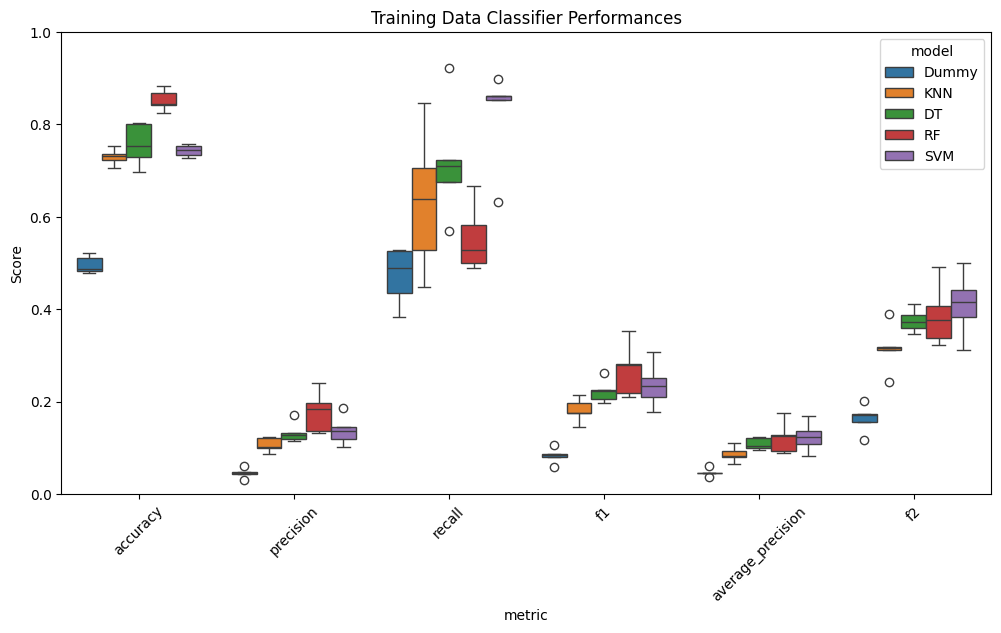

In [68]:
plot_performances([
    ('Dummy', cv_dummy_perf),
    ('KNN', cv_knn_perf),
    ('DT', cv_dt_perf),
    ('RF', cv_rf_perf),
    ('SVM', cv_svm_perf),
])

### Test Data - Hold Out Evaluation

In [63]:
pipelines = [("Dummy", dummy_pipeline), 
             ("DT", oversampled_dt_pipeline), 
             ("KNN", smote_knn_pipeline), 
             ("RF", oversampled_rf_pipeline), 
             ("SVM", svm_pipeline), ]

test_results = evaluate_pipelines_holdout(pipelines, X_train, y_train, X_test, y_test)
test_results

,name,eval_accuracy_score,eval_precision_score,eval_recall_score,eval_f1_score,eval_f2_metric
0,Dummy,0.501957,0.050980,0.509804,0.092692,0.182073
1,DT,0.806262,0.148325,0.607843,0.238462,0.375303
2,KNN,0.747554,0.131673,0.725490,0.222892,0.381443
3,RF,0.858121,0.206250,0.647059,0.312796,0.453297
4,SVM,0.749511,0.137809,0.764706,0.233533,0.400411
